In [61]:
import pandas as pd
import requests
import matplotlib.pyplot as plt

%matplotlib inline

In [62]:
countries = ["TUR", "USA", "DEU", "JPN"]
indicator = "NY.GDP.PCAP.CD"
country_str = ";".join(countries)

url = f"https://api.worldbank.org/v2/country/{country_str}/indicator/{indicator}?format=json&per_page=200"

response = requests.get(url)
data = response.json()

World Bank API üzerinden Türkiye, ABD, Almanya ve Japonya için kişi başı gelir verisi çekildi.

In [63]:
gdp_data = []

for row in data[1]:
    gdp_data.append({"country":row["country"]["value"],"year":row["date"],"gdp_per_capita":row["value"]})

df_gdp= pd.DataFrame(gdp_data)
print(df_gdp.head())
print()
print(df_gdp.info())

   country  year  gdp_per_capita
0  Germany  2025             NaN
1  Germany  2024    56103.732318
2  Germany  2023    54776.766824
3  Germany  2022    50506.517964
4  Germany  2021    52349.245999

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   country         200 non-null    object 
 1   year            200 non-null    object 
 2   gdp_per_capita  196 non-null    float64
dtypes: float64(1), object(2)
memory usage: 4.8+ KB
None


API’den gelen JSON yapıdan ülke, yıl ve kişi başı gelir bilgileri seçildi. Veri seti oluşturuldu ve içeriği kontrol edildi.

In [64]:
df_gdp = df_gdp.dropna()
df_gdp["year"] = df_gdp["year"].astype(int)
df_gdp = df_gdp.sort_values(["country", "year"]).reset_index(drop=True)
df_gdp["gdp_per_capita"] = df_gdp["gdp_per_capita"].round(2)

print(df_gdp.head())
print()
df_gdp.info()

   country  year  gdp_per_capita
0  Germany  1960         1162.12
1  Germany  1961         1315.91
2  Germany  1962         1430.52
3  Germany  1963         1502.15
4  Germany  1964         1637.46

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 196 entries, 0 to 195
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   country         196 non-null    object 
 1   year            196 non-null    int64  
 2   gdp_per_capita  196 non-null    float64
dtypes: float64(1), int64(1), object(1)
memory usage: 4.7+ KB


Eksik veriler silindi, yıl sayıya çevrildi ve tablo düzenlendi.

In [65]:
population_indicator = "SP.POP.TOTL"
url_pop = f"https://api.worldbank.org/v2/country/{country_str}/indicator/{population_indicator}?format=json&per_page=200"

response_pop = requests.get(url_pop)
data_pop = response_pop.json()

Aynı ülkeler için toplam nüfus verisi çekildi.

In [66]:
pop_data = []

for row in data_pop[1]:
    pop_data.append({"country":row["country"]["value"],"year":row["date"],"population_total":row["value"]})

df_pop = pd.DataFrame(pop_data)

Nüfus verisi ülke-yıl yapısında tablo haline getirildi.

In [67]:
print(df_pop.info())
print()
df_pop.head()

df_pop = df_pop.dropna()
df_pop["year"] = df_pop["year"].astype(int)
df_pop = df_pop.sort_values(["country","year"]).reset_index(drop= True)

df = pd.merge(df_gdp,df_pop,on= ["country","year"],validate="one_to_one")
df

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   country           200 non-null    object 
 1   year              200 non-null    object 
 2   population_total  196 non-null    float64
dtypes: float64(1), object(2)
memory usage: 4.8+ KB
None



,country,year,gdp_per_capita,population_total
0,Germany,1960,1162.12,72814900.0
1,Germany,1961,1315.91,73377632.0
2,Germany,1962,1430.52,74025784.0
3,Germany,1963,1502.15,74714353.0
4,Germany,1964,1637.46,75318337.0
...,...,...,...,...
191,Turkiye,2021,9981.76,84147318.0
192,Turkiye,2022,10897.84,84979913.0
193,Turkiye,2023,13375.09,85325965.0
194,Turkiye,2024,15892.72,85518661.0


Eksik veriler temizlendi ve veri seti uygun formata getirildikten sonra hazırlanılan iki veri seti merge ile bileştirildi.

In [68]:
df["total_gdp"] = df["population_total"] * df["gdp_per_capita"]
df["country"].unique()

df = df[df["country"] != "United States"].reset_index(drop=True)

ABD Verisi yalnızca 1 tane olduğu için yorum gücü bulunmadığından veri setinden çıkartıldı

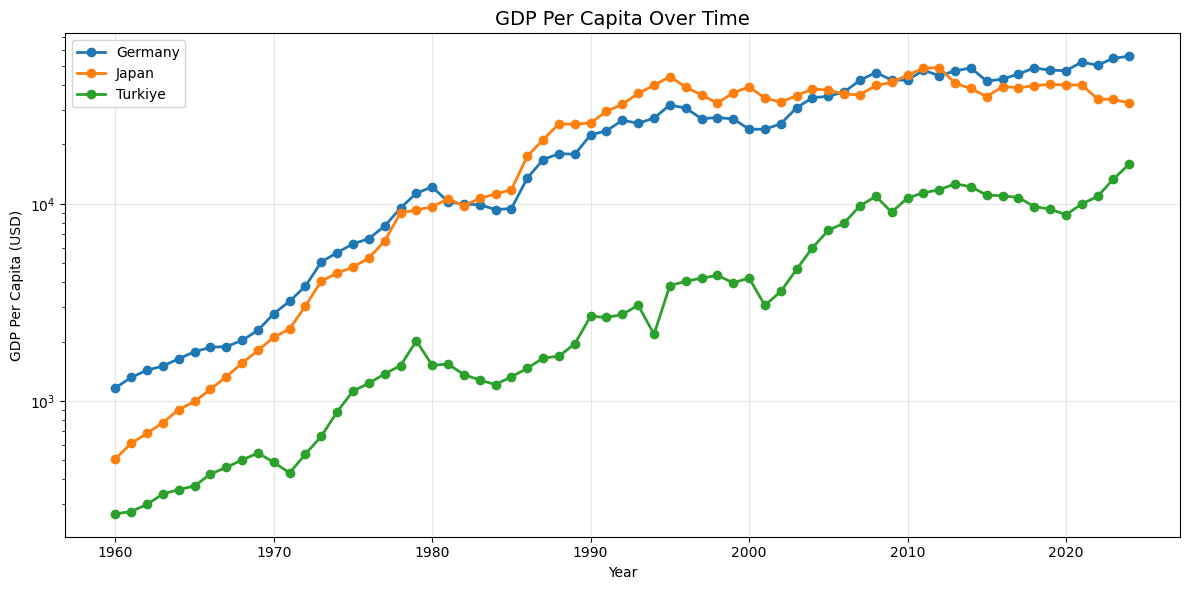

In [69]:
plt.figure(figsize=(12, 6))

for country in df["country"].unique():
    country_data = df[df["country"] == country]
    plt.plot(
        country_data["year"],
        country_data["gdp_per_capita"],
        marker="o",
        linewidth=2,
        label=country
    )

plt.title("GDP Per Capita Over Time", fontsize=14)
plt.xlabel("Year")
plt.ylabel("GDP Per Capita (USD)")
plt.yscale("log")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

General Overview

Başlangıç döneminde Almanya en yüksek kişi başı gelir seviyesine sahipken, Türkiye en düşük seviyededir. Japonya ise bu iki ülke arasında konumlanmaktadır.

⸻

Trend Analysis

Germany:
Almanya, 1980’lere kadar güçlü ve istikrarlı bir büyüme sergilemiştir. Bu dönemden sonra ise dalgalanmalar gözlemlense de genel olarak artış trendini korumuştur ve günümüzde en yüksek seviyede yer almaktadır.

⸻

Japan:
Japonya, belirli dönemlerde Almanya’yı yakalamış ve hatta bazı yıllarda geçmiştir. Ancak 1995 sonrasında büyüme hızının yavaşladığı ve daha yatay bir eğilim izlediği görülmektedir. Günümüzde Almanya’nın gerisinde kalmaktadır.

⸻

Turkey:
Türkiye, diğer iki ülkeye kıyasla daha dalgalı bir büyüme süreci geçirmiştir. Ancak özellikle 2020 sonrasında belirgin bir artış trendine girmiştir. Buna rağmen genel seviyede hâlâ Almanya ve Japonya’nın altında kalmaktadır.

⸻

Final Insight

Tüm ülkeler uzun vadede kişi başı gelirlerini artırmış olsa da, başlangıçtaki sıralama genel olarak korunmuştur:

Germany > Japan > Turkey

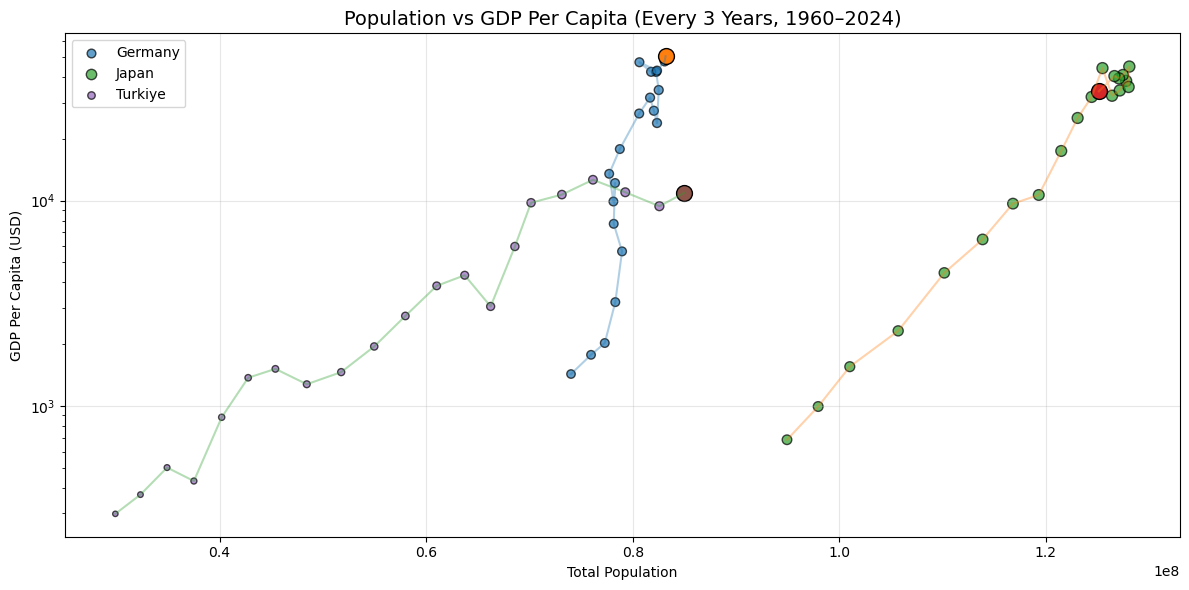

In [70]:
plt.figure(figsize=(12,6))

df_selected= df[df["year"]%3==0]

for country in df_selected["country"].unique():
    temp = df_selected[df_selected["country"]==country]
    plt.scatter(temp["population_total"],temp["gdp_per_capita"],s=temp["population_total"] / 2_000_000,alpha=0.7,label=country,edgecolor="black")
    plt.plot(
    temp["population_total"],
    temp["gdp_per_capita"],
    alpha=0.35
    )
    latest = temp[temp["year"] == temp["year"].max()]
    plt.scatter(
    latest["population_total"],
    latest["gdp_per_capita"],
    s=130,
    edgecolors="black"
    )



plt.xlabel("Total Population",fontsize=10)
plt.ylabel("GDP Per Capita (USD)")
plt.title("Population vs GDP Per Capita (Every 3 Years, 1960–2024)",fontsize = 14)
plt.yscale("log")
plt.grid(True,alpha=0.3)
plt.tight_layout()
plt.legend()
plt.show()  

General Overview

Genel olarak nüfus açısından değerlendirildiğinde, Türkiye en düşük nüfus seviyesinden başlayarak zaman içerisinde Almanya’yı yakalamış ve son yıllarda geçmiş görünmektedir. Japonya ise tüm dönem boyunca en yüksek nüfusa sahip ülke olarak konumunu korumuştur.

Kişi başına düşen gelir açısından bakıldığında ise Türkiye başlangıçta en düşük seviyededir. Zaman içerisinde artış gösterse de Almanya ve Japonya ile arasındaki farkı tamamen kapatamamıştır. Almanya ve Japonya başlangıçta benzer seviyelerde ilerlerken, son yıllarda Almanya’nın Japonya’nın üzerine çıktığı gözlemlenmektedir.

⸻

Country-Based Analysis

Turkey:
Türkiye, zaman içerisinde hem nüfus hem de kişi başı gelir açısından genel bir artış eğilimi göstermektedir. Ancak bu artış doğrusal değildir; belirli dönemlerde ani düşüşler ve dalgalanmalar görülmektedir. Bu durum, ekonomik büyümenin istikrarlı olmadığını göstermektedir.

⸻

Germany:
Almanya, analiz edilen ülkeler arasında en sınırlı nüfus artışına sahip ülkedir. Buna rağmen kişi başı gelir seviyesi sürekli artış eğilimindedir. Bu durum, nüfus artışı ile ekonomik büyüme arasında güçlü bir doğrusal ilişki olmadığını göstermektedir. Almanya’nın ekonomik performansı, daha çok verimlilik ve yapısal faktörlerle açıklanabilir.

⸻

Japan:
Japonya’da belirli bir döneme kadar nüfus artışı ile kişi başı gelir arasında daha güçlü bir ilişki gözlemlenmektedir. Ancak ilerleyen yıllarda nüfus artışı yavaşlamış, hatta durağanlaşmıştır. Bu dönemde kişi başı gelir artışının da yavaşladığı görülmektedir. Bu durum, Japonya ekonomisinin belirli bir olgunluk seviyesine ulaştığını göstermektedir.

⸻

Latest Year Insight

Son verilere göre kişi başı gelir seviyesinde sıralama:

Germany > Japan > Turkey

Bu sıralama, yıllar içerisinde genel eğilim korunarak devam etmiştir.
